In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# **Data Preparation**

In [ ]:
calories= pd.read_csv("/content/calories (1).csv")
exercise= pd.read_csv("/content/exercise.csv")

In [ ]:
df = pd.merge(calories,exercise, on='User_ID')

In [ ]:
df.head()

,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,female,27,154.0,58.0,10.0,81.0,39.8


In [ ]:
df.describe

<bound method NDFrame.describe of         User_ID  Calories  Gender  Age  Height  Weight  Duration  Heart_Rate  \
0      14733363     231.0    male   68   190.0    94.0      29.0       105.0   
1      14861698      66.0  female   20   166.0    60.0      14.0        94.0   
2      11179863      26.0    male   69   179.0    79.0       5.0        88.0   
3      16180408      71.0  female   34   179.0    71.0      13.0       100.0   
4      17771927      35.0  female   27   154.0    58.0      10.0        81.0   
...         ...       ...     ...  ...     ...     ...       ...         ...   
14995  15644082      45.0  female   20   193.0    86.0      11.0        92.0   
14996  17212577      23.0  female   27   165.0    65.0       6.0        85.0   
14997  17271188      75.0  female   43   159.0    58.0      16.0        90.0   
14998  18643037      11.0    male   78   193.0    97.0       2.0        84.0   
14999  11751526      98.0    male   63   173.0    79.0      18.0        92.0   

       Body_Temp  
0           40.8  
1           40.3  
2           38.7  
3           40.5  
4           39.8  
...          ...  
14995       40.4  
14996       39.2  
14997       40.1  
14998       38.3  
14999       40.5  

[15000 rows x 9 columns]>

In [ ]:
df.shape

(15000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   User_ID     15000 non-null  int64  
 1   Calories    15000 non-null  float64
 2   Gender      15000 non-null  object 
 3   Age         15000 non-null  int64  
 4   Height      15000 non-null  float64
 5   Weight      15000 non-null  float64
 6   Duration    15000 non-null  float64
 7   Heart_Rate  15000 non-null  float64
 8   Body_Temp   15000 non-null  float64
dtypes: float64(6), int64(2), object(1)
memory usage: 1.0+ MB


# **Data Cleaning**

In [ ]:
df.isnull().sum()

,0
User_ID,0
Calories,0
Gender,0
Age,0
Height,0
Weight,0
Duration,0
Heart_Rate,0
Body_Temp,0


In [ ]:
df['Gender'].value_counts()

,count
Gender,
female,7553
male,7447


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.replace({'Gender':{'male':0,'female':1}},inplace=True)

/tmp/ipykernel_903/1088024582.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace({'Gender':{'male':0,'female':1}},inplace=True)


In [ ]:
df.head()

,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,0,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,1,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,0,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,1,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,1,27,154.0,58.0,10.0,81.0,39.8


In [ ]:
df.drop('User_ID',axis=1,inplace=True)

# **The "Insight" Phase**

<Axes: xlabel='Calories', ylabel='Heart_Rate'>

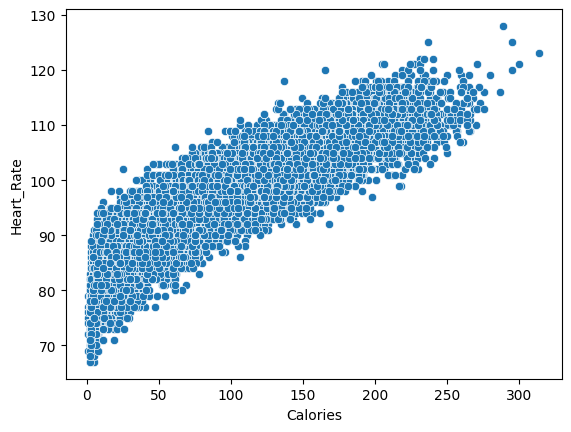

In [ ]:
#creating the scatterplot for heartrate vs calories

sns.scatterplot(x='Calories',y='Heart_Rate',data=df)

<Axes: >

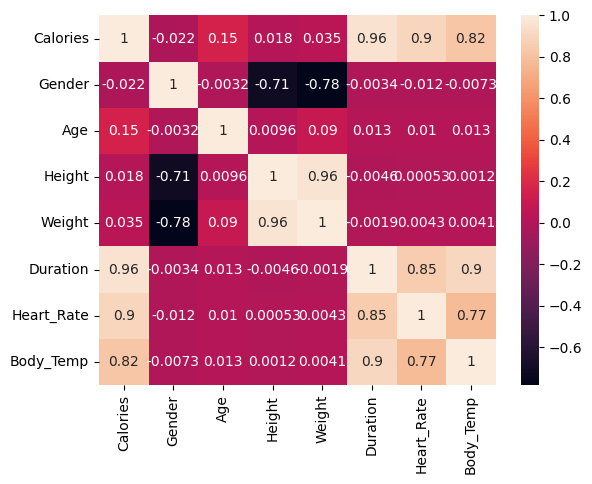

In [ ]:
#creating the heatmap to see the corelation between variables
sns.heatmap(df.corr(),annot=True)

# **Building the ML Model**

In [ ]:
#Spliting  the data into Training (80%) and Testing (20%) sets.
 #Using theRandom Forest Regressor (As it is highly accurate for this  dataset).

In [ ]:
#defines calories as my target variable and other physical attributes as input features
X=  df.drop('Calories',axis=1)
Y = df['Calories']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=2)

In [ ]:
#train the model
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, Y_train)

RandomForestRegressor()

In [ ]:
#Calculating the Mean Absolute Error (MAE).
from sklearn.metrics import mean_absolute_error
y_pred = model.predict(X_test)
mae = mean_absolute_error(Y_test, y_pred)
print("Mean Absolute Error:", mae)

Mean Absolute Error: 1.6736333333333333


An mae is 1.67 which means model's prediction is only 1.67 calories away from the actual calories burnt

In [ ]:
import pickle
from google.colab import files

# Save the model
pickle.dump(model, open('calories_model.sav', 'wb'))

# Download it to your laptop
files.download('calories_model.sav')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>